In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/notebooks"); print("Colab: working in", os.getcwd())

# 2. Continuum and emission-line measurements with pPXF

We measure the lines with **pPXF** (Cappellari 2017, 2023), the standard full-spectrum fitting code. It
fits, in one go, a **stellar continuum** (a non-negative combination of simple stellar populations,
broadened by the stars' velocity dispersion) and **Gaussian emission lines**, each convolved with the
instrument's line-spread function. Because it only needs wavelength, flux, noise and resolution arrays,
the same code runs on DESI and SDSS spectra: no format conversion, one set of numbers for the whole sample.

The steps, one per section: read the spectrum (1), put it on a logarithmic wavelength grid (2), build the
stellar and gas templates (3), fit (4), turn the fitted weights into line fluxes (5), see why the stellar
continuum matters for Hβ (6), test for a broad Hα component (7), cross-check against two other codes (8).

`scripts/run_ppxf.py` does exactly this for every spectrum of the sample; we import its readers and, at
the end, its fit function to check that the notebook reproduces the pipeline.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    # one BLAS thread: on Binder / Colab the pod has
    os.environ.setdefault(_v, "1")                                          # one core and multi-threaded BLAS is 30x slower
import os, sys
from pathlib import Path
import numpy as np, pandas as pd, fitsio
import matplotlib.pyplot as plt
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("DESI_SPECTRO_REDUX", str(ROOT / "output" / "desi_redux"))
import run_ppxf as RP                      # the project's readers and the production fit, so notebook and pipeline agree
C_KMS = 299792.458
plt.rcParams.update({"figure.dpi": 110})
print("repo:", ROOT, "| pPXF", __import__("ppxf").__version__)

repo: /home/eborsato/PyAutoThings/workspace/interbars | pPXF 9.5.0


## 2.1 Read a spectrum

`MY_SYSTEMS` comes from notebook 1; the main galaxy's DESI spectrum is used when there is one, else the
SDSS one (`LABEL` can be set to any other spectrum of the list). The readers return the same five arrays
for both surveys: vacuum wavelength [Å], flux and inverse variance [10⁻¹⁷ erg s⁻¹ cm⁻² Å⁻¹], the
instrumental FWHM at every pixel [Å] (from the DESI resolution matrix, or the SDSS `wdisp`), and a
bad-pixel mask (ivar = 0). `_sdss` labels are SDSS spectra.

spectra of your system(s):
                    system  role source            spec_id      z_in
label                                                               
IC3147B            IC3147B  main   DESI  39628075859711056  0.025627
IC3147B_sdss       IC3147B  main   SDSS     1613-53115-145  0.025578
IC3147B_comp_sdss  IC3147B  comp   SDSS     1614-53120-312  0.025957
IC3147B: DESI, z = 0.02563, 7958 good pixels, 3600-9824 Å, FWHM 1.50-1.85 Å


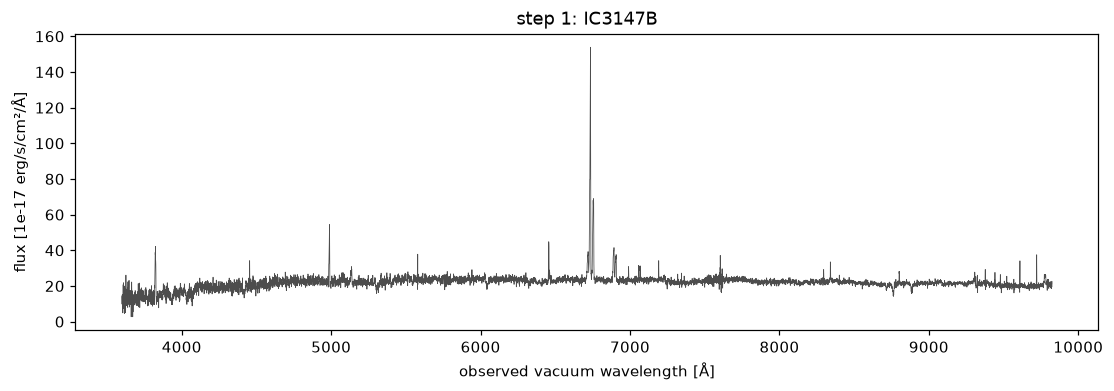

In [2]:
import json
MY_SYSTEMS = json.loads((ROOT / "notebooks/my_systems.json").read_text()) if (ROOT / "notebooks/my_systems.json").exists() else ["IC3147B"]
tg = RP.targets().set_index("label")
print("spectra of your system(s):"); print(tg[tg.system.isin(MY_SYSTEMS)][["system", "role", "source", "spec_id", "z_in"]].to_string())
cand = tg[(tg.system == MY_SYSTEMS[0]) & (tg.role == "main")].sort_values("source")
LABEL = cand.index[0]                         # the main galaxy's DESI spectrum if there is one, else its SDSS one; or set another label here
r = tg.loc[LABEL]; z = float(r.z_in)
if r.source == "DESI":
    lam_vac, flux, ivar, fwhm, mask = RP.read_desi(r.file, r.spec_id)
else:
    RP.fetch_lite(r.file, getattr(r, "run2d", "")); lam_vac, flux, ivar, fwhm, mask = RP.read_sdss(r.file)
good = (ivar > 0) & ~mask
print(f"{LABEL}: {r.source}, z = {z:.5f}, {good.sum()} good pixels, {lam_vac[0]:.0f}-{lam_vac[-1]:.0f} Å, FWHM {fwhm[good].min():.2f}-{fwhm[good].max():.2f} Å")
fig, ax = plt.subplots(figsize=(12, 3.5)); ax.plot(lam_vac, np.where(good, flux, np.nan), lw=0.5, color="0.3")
ax.set(xlabel="observed vacuum wavelength [Å]", ylabel="flux [1e-17 erg/s/cm²/Å]", title=f"step 1: {LABEL}"); plt.show()

## 2.2 Air wavelengths and the logarithmic grid

Two conventions to get right before any fit. **Air vs vacuum**: the E-MILES stellar library is tabulated
at air wavelengths, DESI and SDSS at vacuum ones; we convert the spectrum (`util.vac_to_air`). Forgetting
it shifts every line by ~80 km/s. **Log grid**: a Doppler shift is a constant *fraction* of the wavelength,
so pPXF works on a grid where each pixel is a constant velocity step, `velscale` km/s (`util.log_rebin`).
The noise is rebinned with the variance and the number of original pixels averaged into each new one.

In [3]:
lam_air = util.vac_to_air(lam_vac)
flux_f = np.where(good, flux, np.interp(lam_air, lam_air[good], flux[good]))      # fill bad pixels for the rebinning
var = np.where(good, 1 / np.where(good, ivar, 1), 0.0)
norm = np.median(flux_f[good])                                                   # pPXF likes numbers of order 1
velscale = util.log_rebin(lam_air, flux_f)[2]
galaxy, ln_lam, _ = util.log_rebin(lam_air, flux_f / norm, velscale=velscale)
var_log = util.log_rebin(lam_air, var / norm ** 2, velscale=velscale)[0]
bad_log = util.log_rebin(lam_air, (~good).astype(float), velscale=velscale)[0] > 0.3
lam_gal = np.exp(ln_lam)
npix_per = np.clip(lam_gal * velscale / C_KMS / np.median(np.diff(lam_air)), 1, None)
noise = np.sqrt(np.clip(var_log / npix_per, 1e-8, None)); noise[bad_log] = 1e3
fwhm_gal = {"lam": lam_gal, "fwhm": np.interp(lam_gal, lam_air, fwhm)}
print(f"velscale = {velscale:.1f} km/s per pixel; {len(galaxy)} log pixels; median S/N per pixel = {np.median(galaxy[~bad_log] / noise[~bad_log]):.1f}")

velscale = 37.8 km/s per pixel; 7958 log pixels; median S/N per pixel = 21.1


## 2.3 Templates: stars and gas

**Stars**: the E-MILES simple stellar populations (Vazdekis et al. 2016), a grid in age and metallicity.
`sps_lib` loads them, degrades them to the spectrum's FWHM(λ) where the library is sharper, and puts
them on the same velocity grid. **Gas**: one Gaussian per emission line at the instrumental width
(`emission_lines`); pPXF then fits the extra, astrophysical broadening. Doublets with fixed atomic
ratios ([O III], [N II], [O I]) are single templates; the [S II] and [O II] doublets stay free.

Kinematic **components**: 0 = stars, 1 = Balmer lines, 2 = forbidden lines. Lines in the same component
share velocity and width; recombination and collisionally excited lines need not.

150 stellar templates: 25 ages x 6 metallicities, 0.06-15.8 Gyr
Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
gas templates: [np.str_('H10'), np.str_('H9'), np.str_('H8'), np.str_('Heps'), np.str_('Hdelta'), np.str_('Hgamma'), np.str_('Hbeta'), np.str_('Halpha'), np.str_('[OII]3726'), np.str_('[OII]3729'), np.str_('[SII]6716'), np.str_('[SII]6731'), np.str_('[NeIII]3968'), np.str_('[NeIII]3869'), np.str_('HeII4687'), np.str_('HeI5876'), np.str_('[OIII]5007_d'), np.str_('[OI]6300_d'), np.str_('[NII]6583_d')]


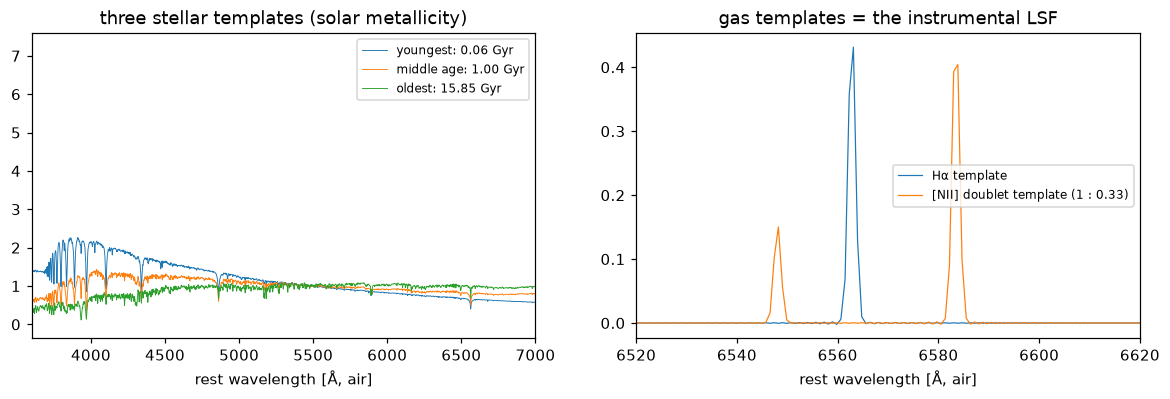

In [4]:
sps = lib.sps_lib(ROOT / "output/ppxf/sps_models/spectra_emiles_9.0.npz", velscale, fwhm_gal, norm_range=[5070, 5950])
reg_dim = sps.templates.shape[1:]; stars = sps.templates.reshape(sps.templates.shape[0], -1)
print(f"{stars.shape[1]} stellar templates: {reg_dim[0]} ages x {reg_dim[1]} metallicities, {sps.age_grid.min():.2f}-{sps.age_grid.max():.1f} Gyr")
lam_range_gal = np.array([lam_gal[0], lam_gal[-1]]) / (1 + z)
gas, gas_names, line_wave = util.emission_lines(sps.ln_lam_temp, lam_range_gal, fwhm_gal, tie_balmer=False, limit_doublets=False)
print("gas templates:", list(gas_names))
templates = np.column_stack([stars, gas])
n_temps = stars.shape[1]; forb = np.array(["[" in n for n in gas_names])
component = [0] * n_temps + [2 if f else 1 for f in forb]; gas_component = np.array(component) > 0

fig, axs = plt.subplots(1, 2, figsize=(13, 3.6))
for (ia, im, lab) in [(0, 2, "youngest"), (reg_dim[0] // 2, 2, "middle age"), (reg_dim[0] - 1, 2, "oldest")]:
    t = sps.templates[:, ia, im]; v = (sps.lam_temp > 5070) & (sps.lam_temp < 5950)          # normalise in the V band, not over 0.1-5 µm
    axs[0].plot(sps.lam_temp, t / np.mean(t[v]), lw=0.6, label=f"{lab}: {sps.age_grid[ia, im]:.2f} Gyr")
axs[0].set(xlim=(3600, 7000), xlabel="rest wavelength [Å, air]", title="three stellar templates (solar metallicity)"); axs[0].legend(fontsize=8)
i = list(gas_names).index("Halpha"); axs[1].plot(sps.lam_temp, gas[:, i], lw=0.8, label="Hα template"); i2 = list(gas_names).index("[NII]6583_d"); axs[1].plot(sps.lam_temp, gas[:, i2], lw=0.8, label="[NII] doublet template (1 : 0.33)")
axs[1].set(xlim=(6520, 6620), xlabel="rest wavelength [Å, air]", title="gas templates = the instrumental LSF"); axs[1].legend(fontsize=8); plt.show()

## 2.4 The fit

One call. Choices worth knowing: `moments=[2, 2, 2]` fits velocity and dispersion for each component;
`degree=-1, mdegree=10` uses a *multiplicative* polynomial only (it absorbs flux-calibration ripples
without touching the line strengths, unlike an additive one); `bounds` keep the narrow widths below
500 km/s; the sky line at 5577 Å and the telluric A band are excluded via `goodpixels`.

chi2/dof = 2.03
  stars      V =   7536.7 km/s (z = 0.02546)   sigma =   93.0 km/s
  Balmer     V =   7598.7 km/s (z = 0.02567)   sigma =  128.7 km/s
  forbidden  V =   7562.8 km/s (z = 0.02555)   sigma =  149.1 km/s
  light-weighted age 9.2 Gyr, [M/H] -0.21


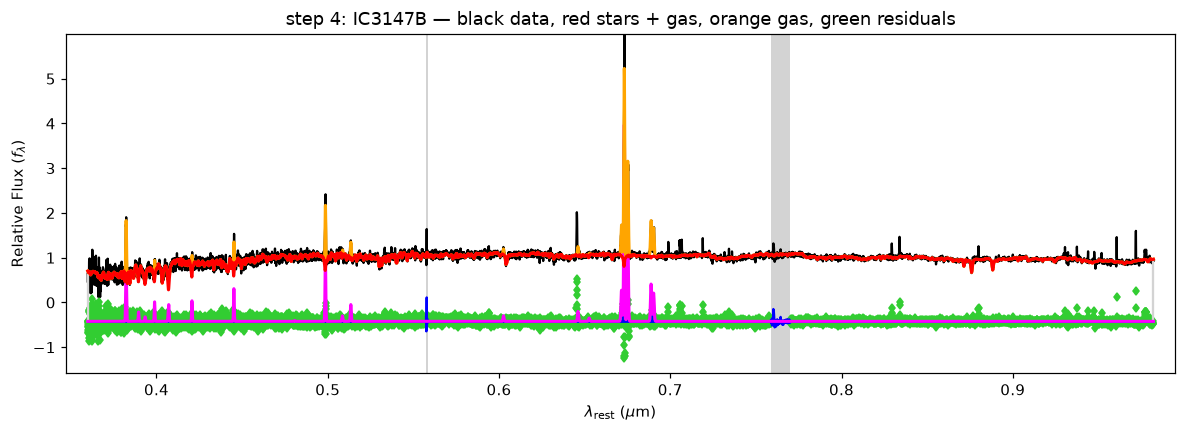

In [5]:
vel = C_KMS * np.log(1 + z); start = [[vel, 150.0], [vel, 100.0], [vel, 100.0]]
goodpixels = np.where(~bad_log & ~((lam_gal > 5573) & (lam_gal < 5583)) & ~((lam_gal > 7590) & (lam_gal < 7700)))[0]
bounds = [[[vel - 1500, vel + 1500], [10, 500]]] * 3
pp = ppxf(templates, galaxy, noise, velscale, start, moments=[2, 2, 2], degree=-1, mdegree=10, lam=lam_gal, lam_temp=sps.lam_temp,
          component=component, gas_component=gas_component, gas_names=gas_names, goodpixels=goodpixels, bounds=bounds, quiet=True)
print(f"chi2/dof = {pp.chi2:.2f}")
for k, name in enumerate(["stars", "Balmer", "forbidden"]):
    print(f"  {name:10s} V = {pp.sol[k][0]:8.1f} km/s (z = {np.exp(pp.sol[k][0] / C_KMS) - 1:.5f})   sigma = {pp.sol[k][1]:6.1f} km/s")
age, met = sps.mean_age_metal(pp.weights[:n_temps].reshape(reg_dim), quiet=True)
print(f"  light-weighted age {age:.1f} Gyr, [M/H] {met:+.2f}")
plt.figure(figsize=(13, 4)); pp.plot(); plt.title(f"step 4: {LABEL} — black data, red stars + gas, orange gas, green residuals"); plt.show()

## 2.5 From weights to line fluxes

pPXF returns `pp.gas_flux` in the units of the input spectrum *per pixel*: multiply by the pixel size
in Å at the observed line (λ · velscale / c) and by the normalisation to get erg s⁻¹ cm⁻². For the fixed
doublet templates the strong line is the template flux divided by 1.33. Errors are the formal ones.

In [6]:
rows = []
for name, fl, er, lw in zip(gas_names, pp.gas_flux, pp.gas_flux_error, line_wave):
    if name in RP.GAS:
        key, fac = RP.GAS[name]; dlam = lw * (1 + z) * velscale / C_KMS
        rows.append(dict(line=name, key=key, flux=fl * dlam * norm / fac, err=er * dlam * norm / fac))
L = pd.DataFrame(rows).set_index("key"); L["snr"] = L.flux / L.err
print(L.round(2).to_string())
n2, o3 = np.log10(L.loc["nii", "flux"] / L.loc["ha", "flux"]), np.log10(L.loc["oiii", "flux"] / L.loc["hb", "flux"])
print(f"\nlog([NII]/Hα) = {n2:+.3f}   log([OIII]/Hβ) = {o3:+.3f}   Hα/Hβ = {L.loc['ha', 'flux'] / L.loc['hb', 'flux']:.2f}")

                 line    flux   err     snr
key                                        
hd             Hdelta   49.35  3.30   14.97
hg             Hgamma   82.18  3.21   25.61
hb              Hbeta  180.37  3.39   53.19
ha             Halpha  725.73  3.77  192.42
oii3726     [OII]3726   88.92  5.29   16.81
oii3729     [OII]3729   80.35  5.00   16.05
sii6716     [SII]6716  162.37  2.91   55.75
sii6731     [SII]6731  123.21  2.81   43.88
oiii     [OIII]5007_d   55.05  3.10   17.77
oi         [OI]6300_d   40.60  2.58   15.75
nii       [NII]6583_d  401.72  3.15  127.71

log([NII]/Hα) = -0.257   log([OIII]/Hβ) = -0.515   Hα/Hβ = 4.02


## 2.6 Why the stellar continuum matters

`pp.bestfit - pp.gas_bestfit` is the stellar model. Under Hβ it dips into the Balmer absorption trough;
a straight line drawn across the line would sit above it and swallow part of the emission. The Hα panel
shows the same, weaker, effect.

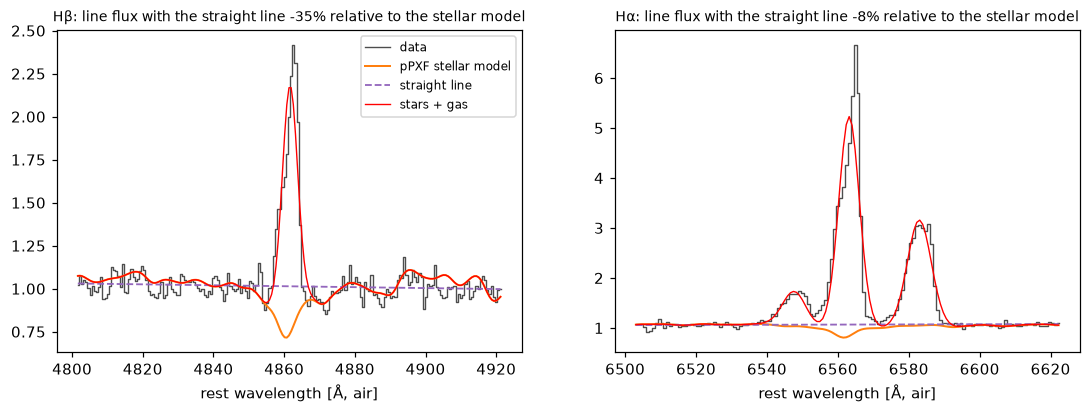

In [7]:
stars_fit = pp.bestfit - pp.gas_bestfit; rest = lam_gal / (1 + z)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (l0, name) in zip(axs, [(4861.3, "Hβ"), (6562.8, "Hα")]):
    s = (rest > l0 - 60) & (rest < l0 + 60); side = s & (np.abs(rest - l0) > 25)
    p = np.polyfit(rest[side], galaxy[side], 1)
    ax.plot(rest[s], galaxy[s], color="0.3", lw=0.9, drawstyle="steps-mid", label="data"); ax.plot(rest[s], stars_fit[s], color="tab:orange", lw=1.3, label="pPXF stellar model")
    ax.plot(rest[s], np.polyval(p, rest[s]), "--", color="tab:purple", lw=1.2, label="straight line"); ax.plot(rest[s], pp.bestfit[s], "r", lw=0.9, label="stars + gas")
    core = s & (np.abs(rest - l0) < 10); ft = np.trapezoid((galaxy - stars_fit)[core], rest[core]); fn = np.trapezoid((galaxy - np.polyval(p, rest))[core], rest[core])
    ax.set_title(f"{name}: line flux with the straight line {fn / ft - 1:+.0%} relative to the stellar model", fontsize=9); ax.set_xlabel("rest wavelength [Å, air]")
axs[0].legend(fontsize=8); plt.show()

## 2.7 Is there a broad component?

A type-1 AGN adds broad (thousands of km/s) Balmer lines. We add a **fourth component**, a second copy of
the Balmer templates with a width between 500 and 5000 km/s, refit, and keep it only if it is
*physical*: the total χ² drops by more than 25, the broad Hα has S/N > 5, its width is away from both
bounds, and its flux is at least 30 % of the narrow Hα. Without the last three conditions a "broad
component" gets adopted in most spectra as a continuum fudge parked at a bound. Compare IC 3147B with
NGC 1346 (`LABEL = "MCG-01-09-041_comp_sdss"`), a Seyfert 1.

Δχ² = 193   broad Hα S/N = 16.1   σ_broad = 500 km/s   broad/narrow Hα = 0.17
tests: {'dchi2_gt_25': np.True_, 'snr_gt_5': np.True_, 'sigma_in_range': np.False_, 'broad_over_narrow_gt_0p3': np.False_} -> narrow-only model kept


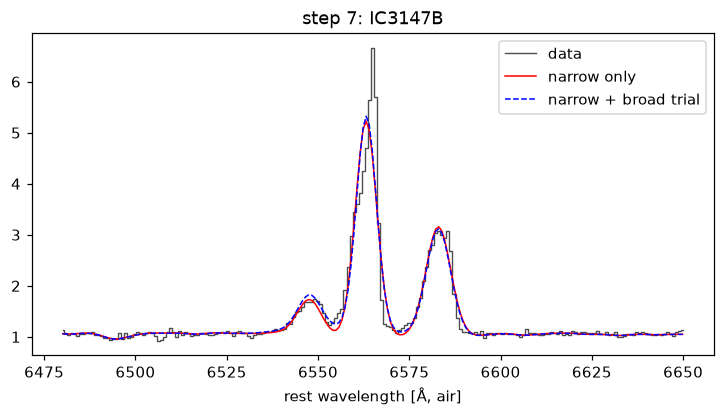

In [8]:
balmer = ~forb; ib = int(np.where(gas_names == "Halpha")[0][0])
templates_b = np.column_stack([templates, gas[:, balmer]]); component_b = component + [3] * int(balmer.sum())
gas_names_b = np.concatenate([gas_names, [n + "_broad" for n in gas_names[balmer]]])
pp_b = ppxf(templates_b, galaxy, noise, velscale, start + [[vel, 1500.0]], moments=[2, 2, 2, 2], degree=-1, mdegree=10, lam=lam_gal, lam_temp=sps.lam_temp,
            component=component_b, gas_component=np.array(component_b) > 0, gas_names=gas_names_b, goodpixels=goodpixels,
            bounds=bounds + [[[vel - 3000, vel + 3000], [500, 5000]]], quiet=True)
ibb = int(np.where(gas_names_b == "Halpha_broad")[0][0])
dchi2 = (pp.chi2 - pp_b.chi2) * len(goodpixels); snr_b = pp_b.gas_flux[ibb] / pp_b.gas_flux_error[ibb]; sig_b = pp_b.sol[3][1]; ratio_b = pp_b.gas_flux[ibb] / pp_b.gas_flux[ib]
tests = dict(dchi2_gt_25=dchi2 > 25, snr_gt_5=snr_b > 5, sigma_in_range=600 < sig_b < 4500, broad_over_narrow_gt_0p3=ratio_b > 0.3)
print(f"Δχ² = {dchi2:.0f}   broad Hα S/N = {snr_b:.1f}   σ_broad = {sig_b:.0f} km/s   broad/narrow Hα = {ratio_b:.2f}")
print("tests:", tests, "->", "BROAD COMPONENT ADOPTED" if all(tests.values()) else "narrow-only model kept")
s = (rest > 6480) & (rest < 6650)
fig, ax = plt.subplots(figsize=(8, 3.8)); ax.plot(rest[s], galaxy[s], color="0.3", lw=0.9, drawstyle="steps-mid", label="data")
ax.plot(rest[s], pp.bestfit[s], "r", lw=1, label="narrow only"); ax.plot(rest[s], pp_b.bestfit[s], "b--", lw=1, label="narrow + broad trial")
ax.set(xlabel="rest wavelength [Å, air]", title=f"step 7: {LABEL}"); ax.legend(); plt.show()

## 2.8 Cross-checks

`RP.fit_one` is the production function (same steps, plus the broad test): it should reproduce the
numbers above. For DESI spectra, FastSpecFit (the DESI collaboration's code) was also run; for SDSS
spectra the SDSS pipeline's own Gaussian fits (`SPZLINE`) exist. `results/tables/line_fitter_comparison.csv`
collects them: agreement to a few percent, except Hβ where the SDSS pipeline sits ~15 % low because it
under-corrects the Balmer absorption of 2.6.

In [9]:
prod = RP.fit_one(lam_vac, flux, ivar, fwhm, mask, z, ROOT / "output/ppxf/sps_models/spectra_emiles_9.0.npz", LABEL, plot=False)
cmp = pd.DataFrame({"notebook": L.flux, "pipeline (run_ppxf)": [prod[f"{k}_flux"] for k in L.index]}, index=L.index)
lf = pd.read_csv(ROOT / "results/tables/line_fitter_comparison.csv").set_index("label")
if LABEL in lf.index:
    for k in ("hb", "oiii", "ha", "nii"):
        cmp.loc[k, "FastSpecFit"] = lf.loc[LABEL, f"{k}_fsf"]
        if r.source == "SDSS": cmp.loc[k, "SDSS pipeline"] = lf.loc[LABEL, f"{k}_sdsspipe"]
print(cmp.round(1).to_string())

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


         notebook  pipeline (run_ppxf)  FastSpecFit
key                                                
hd           49.3                 49.3          NaN
hg           82.2                 82.2          NaN
hb          180.4                180.4        189.1
ha          725.7                725.7        728.8
oii3726      88.9                 88.9          NaN
oii3729      80.3                 80.3          NaN
sii6716     162.4                162.4          NaN
sii6731     123.2                123.2          NaN
oiii         55.1                 55.1         61.7
oi           40.6                 40.6          NaN
nii         401.7                401.7        423.7


## 2.9 The whole sample against the archival line fluxes

Every spectrum we fitted also has a published measurement: the **DESI DR1 value-added catalogue**
`stellar_mass_emline` (Gaussian fits after continuum subtraction, one row per DESI target, queried
from the NOIRLab Data Lab) and, for SDSS, the **SDSS pipeline** fits stored in each lite file
(`SPZLINE`: `LINEAREA`, `LINEAREA_ERR`). Same photons, different code — the comparison tells us how
much of a line flux is method. Points: one per spectrum of the sample, S/N > 3 on both sides.
Requires internet for the DESI part.

/home/eborsato/miniconda3/envs/fastspecfit/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


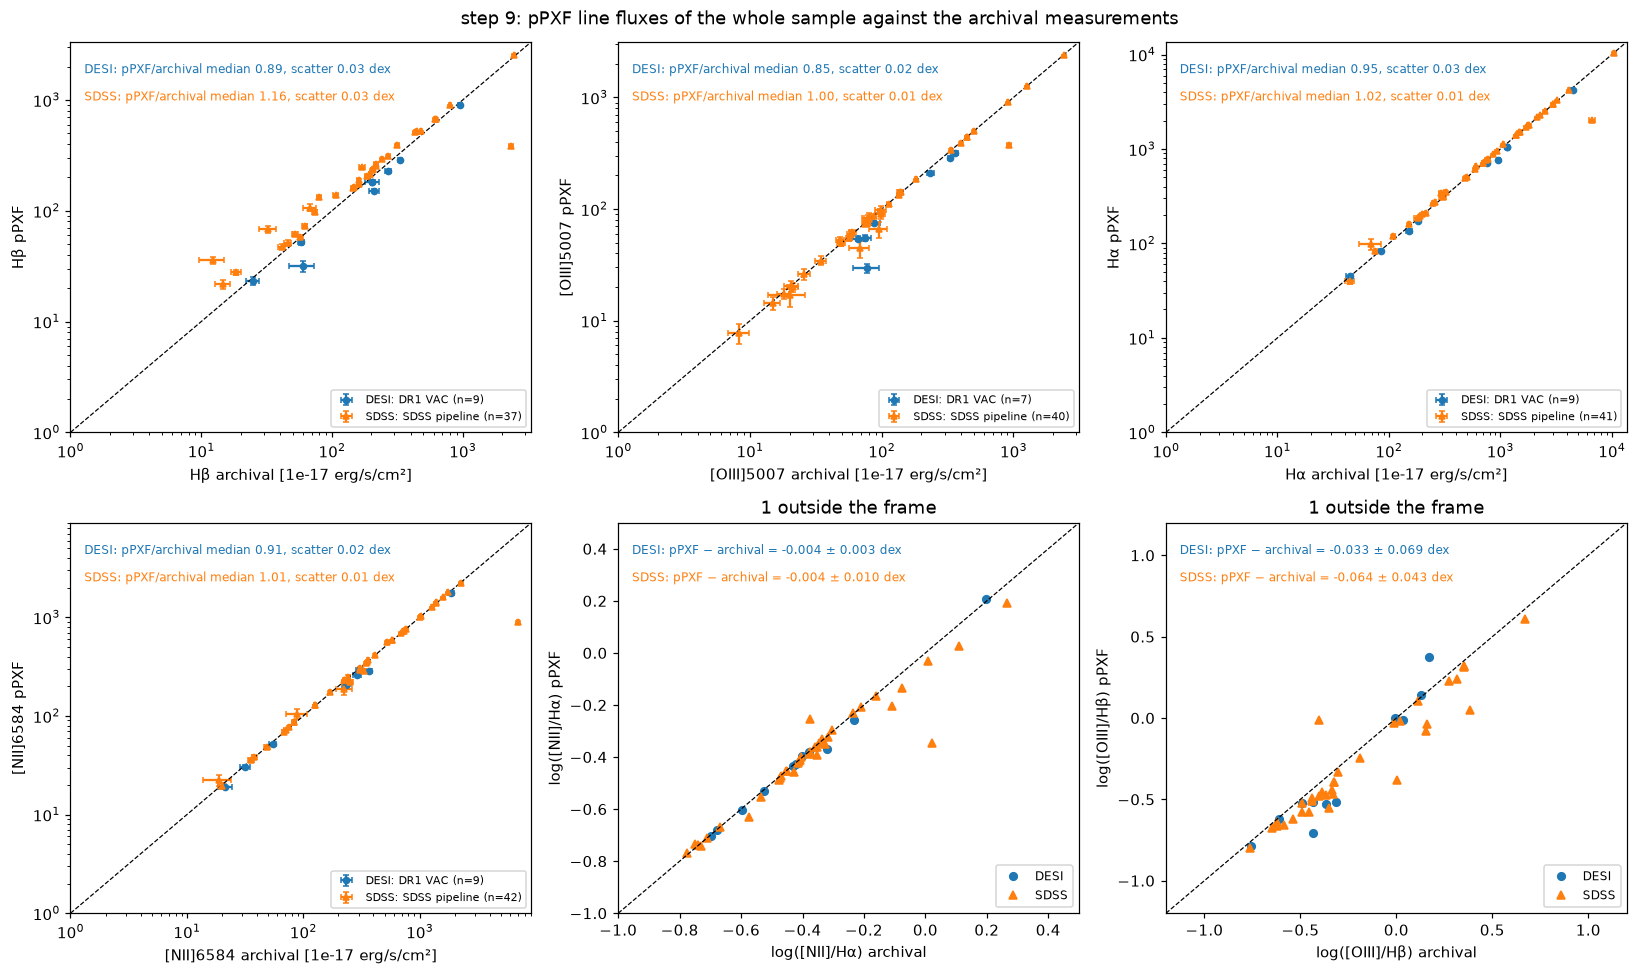

In [10]:
import requests, io
import compare_line_fitters as CLF
T = pd.read_csv(ROOT / "results/tables/ppxf_lines.csv").set_index("label")
KEYS = {"hb": ("hbeta", "Hβ"), "oiii": ("oiii5007", "[OIII]5007"), "ha": ("halpha", "Hα"), "nii": ("nii6583", "[NII]6584")}
arch = pd.DataFrame(index=T.index)
# DESI: one query for all targetids
ids = ",".join(T[T.source == "DESI"].spec_id.astype(str))
try:
    q = f"SELECT targetid, halpha_flux, halpha_fluxerr, hbeta_flux, hbeta_fluxerr, nii6583_flux, nii6583_fluxerr, oiii5007_flux, oiii5007_fluxerr FROM desi_dr1.stellar_mass_emline WHERE targetid IN ({ids})"
    rr = requests.post("https://datalab.noirlab.edu/tap/sync", data=dict(REQUEST="doQuery", LANG="ADQL", FORMAT="csv", QUERY=q), timeout=180)
    v = pd.read_csv(io.StringIO(rr.text)).drop_duplicates("targetid").set_index("targetid")
    for lab, rw in T[T.source == "DESI"].iterrows():
        tid = int(rw.spec_id)
        if tid in v.index:
            for k, (vk, _) in KEYS.items():
                arch.loc[lab, f"{k}_arch"], arch.loc[lab, f"{k}_arch_err"] = v.loc[tid, f"{vk}_flux"], v.loc[tid, f"{vk}_fluxerr"]
except Exception as e:
    print("DESI VAC query failed (offline?):", e)
# SDSS: the pipeline's SPZLINE table of each lite file
for lab, rw in T[T.source == "SDSS"].iterrows():
    f = Path(tg.loc[lab, "file"])
    if f.exists():
        sp = CLF.spzline(f)
        for k in KEYS:
            arch.loc[lab, f"{k}_arch"], arch.loc[lab, f"{k}_arch_err"] = sp[f"{k}_sdsspipe"], sp[f"{k}_sdsspipe_err"]
A = T.join(arch)
fig, axs = plt.subplots(2, 3, figsize=(15, 9)); axs = axs.ravel()
for ax, (k, (_, name)) in zip(axs[:4], KEYS.items()):
    for src, mk, col in (("DESI", "o", "tab:blue"), ("SDSS", "^", "tab:orange")):
        g = A[(A.source == src) & (A[f"{k}_snr"] > 3) & (A[f"{k}_arch"] / A[f"{k}_arch_err"] > 3)]
        ax.errorbar(g[f"{k}_arch"], g[f"{k}_flux"], xerr=g[f"{k}_arch_err"], yerr=g[f"{k}_err"], fmt=mk, ms=4, capsize=2, color=col, label=f"{src}: {'DR1 VAC' if src == 'DESI' else 'SDSS pipeline'} (n={len(g)})")
        q = (g[f"{k}_flux"] / g[f"{k}_arch"]).values; q = q[np.isfinite(q) & (q > 0)]
        if len(q): ax.text(0.03, 0.92 - 0.07 * (src == "SDSS"), f"{src}: pPXF/archival median {np.median(q):.2f}, scatter {1.4826 * np.median(np.abs(np.log10(q) - np.median(np.log10(q)))):.2f} dex", transform=ax.transAxes, fontsize=8, color=col)
    lim = np.nanmax(A[[f"{k}_flux", f"{k}_arch"]].values) * 1.3; ax.plot([1, lim], [1, lim], "k--", lw=0.8)
    ax.set(xscale="log", yscale="log", xlim=(1, lim), ylim=(1, lim), xlabel=f"{name} archival [1e-17 erg/s/cm²]", ylabel=f"{name} pPXF"); ax.legend(fontsize=7, loc="lower right")
for ax, (a_, b_, lab_) in zip(axs[4:], [("nii", "ha", "log([NII]/Hα)"), ("oiii", "hb", "log([OIII]/Hβ)")]):
    ok = (A[f"{a_}_snr"] > 3) & (A[f"{b_}_snr"] > 3) & (A[f"{a_}_arch"] > 0) & (A[f"{b_}_arch"] > 0)
    x = np.log10(A[f"{a_}_arch"] / A[f"{b_}_arch"]); y = np.log10(A[f"{a_}_flux"] / A[f"{b_}_flux"])
    for src, mk, col in (("DESI", "o", "tab:blue"), ("SDSS", "^", "tab:orange")):
        m = ok & (A.source == src); ax.plot(x[m], y[m], mk, ms=5, color=col, label=src)
        d_ = (y - x)[m].dropna(); ax.text(0.03, 0.92 - 0.07 * (src == "SDSS"), f"{src}: pPXF − archival = {d_.median():+.3f} ± {1.4826 * np.median(np.abs(d_ - d_.median())):.3f} dex", transform=ax.transAxes, fontsize=8, color=col)
    lo, hi = (-1.0, 0.5) if a_ == "nii" else (-1.2, 1.2)               # the BPT range; a few pipeline outliers fall outside
    nout = int(((x[ok] < lo) | (x[ok] > hi) | (y[ok] < lo) | (y[ok] > hi)).sum())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8); ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel=lab_ + " archival", ylabel=lab_ + " pPXF", title=f"{nout} outside the frame" if nout else ""); ax.legend(fontsize=8, loc="lower right")
fig.suptitle("step 9: pPXF line fluxes of the whole sample against the archival measurements"); fig.tight_layout(); plt.show()
A[[f"{k}_flux" for k in KEYS] + [f"{k}_arch" for k in KEYS]].to_csv(ROOT / "output/notebooks/archival_flux_comparison.csv")

What to take from it: [O III], Hα and [N II] agree with both archives to a few percent, with 0.01 dex
scatter against the SDSS pipeline — those lines are robust to the method. Hβ is the exception: pPXF is
~15 % above the SDSS pipeline and a few percent off the DESI catalogue, because the codes treat the stellar
absorption under Hβ differently. On the BPT the [N II]/Hα axis is therefore method-independent; the
[O III]/Hβ axis carries a method systematic of a few hundredths of a dex, comparable to the
distance between the Kauffmann and Kewley lines for our composite objects. Classifications near a line
should be quoted with that in mind.

## Exercises

1. Run the notebook on the SDSS spectrum of the same galaxy (`IC3147B_sdss`, 3″ fibre): which line
   fluxes change most, which ratios least? Why?
2. Set `mdegree=0` and refit. What happens to the continuum fit and to the Hβ flux?
3. Tie the Balmer lines to their case-B ratios (`tie_balmer=True` in `emission_lines`, then `gas_reddening=0`
   in `ppxf`): pPXF now fits a gas reddening. Compare it with the Hα/Hβ value of 2.5.
4. Loosen the broad-line test to Δχ² > 25 alone. How many of the four criteria does IC 3147B pass? Which
   parameter is at a bound?
5. `pp.weights[:n_temps]` are the light fractions of the stellar templates: plot them on the age-metallicity
   grid. Is the nucleus old or young? Does `sps.mean_age_metal` agree with your eye?